In [ ]:
import dotenv
%load_ext dotenv
%dotenv

import os
import platform
import json
import random
import time

import jax
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from absl import app, flags
from ml_collections import config_flags

from agents import agents
from envs.env_utils import make_env_and_datasets
from utils.datasets import Dataset, ReplayBuffer
from utils.evaluation import evaluate, flatten, supply_rng
from utils.flax_utils import restore_agent

import jax
import numpy as np
import matplotlib.pyplot as plt

def supply_rng(f, rng=jax.random.PRNGKey(0)):
    """Helper function to split the random number generator key before each call to the function."""

    def wrapped(*args, **kwargs):
        nonlocal rng
        rng, key = jax.random.split(rng)
        return f(*args, seed=key, **kwargs)

    return wrapped

# Configuration
env_name = "antmaze-large-navigate-singletask-task2-v0"
seed = 0
buffer_size = 2000000
eval_episodes = 50

# Agent paths and epochs
a5_jacb_reg_e5_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_173407_utd-ratio1"
# a3_jacb_reg_e5_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_174856_utd-ratio1"
a3_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_195824_utd-ratio1"
a3_hess_reg_e5_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250905_164434_utd-ratio1"
a3_jacb_reg_e6_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_200256_utd-ratio1"
a5_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_115351_utd-ratio1"

# agent_path=a5_jacb_reg_e5_agent_path
agent_path=a3_jacb_reg_e6_agent_path
restore_epoch=1000000

# Make environment and datasets
env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

# Initialize random seeds
random.seed(seed)
np.random.seed(seed)
example_batch = train_dataset.sample(1)

# Load FQL agent configuration and create agent
from agents.iql import get_config as get_iql_config
iql_config = get_iql_config()

iql_agent_class = agents[iql_config['agent_name']]
iql_agent_jcb = iql_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    iql_config,
)

# Restore trained models
if agent_path and restore_epoch:
    iql_agent_jcb = restore_agent(iql_agent_jcb, agent_path, restore_epoch)
    print(f"IQL agent restored from {agent_path} at epoch {restore_epoch}")

print("Models loaded successfully!")


The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv
Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_200256_utd-ratio1/params_1000000.pkl
IQL agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/iql_antmaze-large-navigate-singletask-task2-v0_sd000_20250904_200256_utd-ratio1 at epoch 1000000
Models loaded successfully!


In [64]:
# Generate trajectories for both agents
print("Generating trajectories for IQL agent...")
iql_eval_info, iql_trajs, iql_renders = evaluate(
    agent=iql_agent,
    env=eval_env,
    config=iql_config,
    num_eval_episodes=eval_episodes,
    num_video_episodes=0,  # Skip video rendering for now
)

print(iql_eval_info)

Generating trajectories for IQL agent...


100%|██████████| 50/50 [01:53<00:00,  2.27s/it]

defaultdict(<class 'list'>, {'xy': 12.258612121381502, 'prev_qpos': 1.7034672719624977, 'prev_qvel': -0.0023622735998353687, 'qpos': 1.6997205931513875, 'qvel': -0.07263239655759611, 'success': 0.76, 'total.timesteps': 18344.0, 'episode.final_reward': -0.24, 'episode.return': -691.98, 'episode.length': 692.74, 'episode.duration': 2.264227409362793})


In [65]:
# Get failure cases
success_trajs = []
failed_trajs = []
for i in range(eval_episodes):
    if not iql_trajs[i]['info'][-1]['success']:
        failed_trajs.append(iql_trajs[i])
    else:
        success_trajs.append(iql_trajs[i])

In [ ]:
target_idx = 4
failure_case = failed_trajs[target_idx] # For analysis purpose

observations = failure_case['observation']
positions = np.array(observations)[:,:2]

# Scatter plot of positions (color over the timesteps)
plt.scatter(positions[:,0], positions[:,1], c=np.arange(len(positions)))
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Positions')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
for i in range(len(success_trajs)):
    observations = success_trajs[i]['observation']
    positions = np.array(observations)[:,:2]
    plt.scatter(positions[:,0], positions[:,1], c=np.arange(len(positions)))
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Positions')
    plt.grid(True, alpha=0.3)
    plt.show()

### Change of Policy behavior by differing agent pose

In [66]:
set_x, set_y = 21, 22.7
set_ob = None

# Retriever realistic observation from one of the success cases
for traj in success_trajs:
    observations = np.array(traj['observation'])

    # Retriever states that are close to the set_x and set_y
    condition = np.where((np.abs(observations[:,0] - set_x) < 0.6) & (np.abs(observations[:,1] - set_y) < 0.6))
    if condition[0].shape[0] > 0:
        # uniform sample from condition
        set_ob = observations[np.random.choice(condition[0])]
        break

if set_ob is not None:
    print("set observation: ", set_ob)
    print("position: ", set_ob[:2])
else:
    print("set observation not found")

set observation:  [20.73782513 22.60779457  0.53119122  0.69660394 -0.07424154 -0.07026415
 -0.71013667  0.52464386  1.08333348 -0.41564888 -0.61936271 -0.30365568
 -0.51806955  0.33977177  0.55919562  0.30854355 -1.70061946 -1.55249643
 -0.15111925  2.43599319 -2.36221347 -1.47281809 -2.77335412  3.07613146
 -1.60311916  3.62484503 -0.07082541 -0.67918418  0.75242144]
position:  [20.73782513 22.60779457]


In [67]:
q_pos_dim = 15

_, _ = eval_env.reset()
eval_env.set_state(set_ob[:q_pos_dim], set_ob[q_pos_dim:])

# Actor generation
iql_actor_fn = supply_rng(iql_agent.sample_actions, rng=jax.random.PRNGKey(np.random.randint(0, 2**32)))
eval_temperature = 0

action = iql_actor_fn(observations=set_ob, temperature=eval_temperature)
action = np.clip(action, -1, 1)
true_action_q_val = iql_agent.network.select('critic')(set_ob, action)
print("action: ", action)

next_ob, reward, terminated, truncated, info = eval_env.step(action)
next_ob[:2]

true_q_val = iql_agent.network.select('critic')(set_ob, action)
true_v_val = iql_agent.network.select('value')(next_ob)

true_direction = next_ob[:2] - set_ob[:2]
print("true_direction: ", true_direction)

action:  [-0.89733505  0.7305032  -0.26054472 -0.8616918   0.93382275  0.3708117
  0.9356524   0.51503074]
true_direction:  [ 0.02201996 -0.12785178]


In [68]:
# Policy behavior change by different agnet pose

num_trials = 100
perturbation_range = 0.05

next_observations = []
q_vals = []
v_vals = []

for _ in tqdm(range(num_trials)):
    _, _ = eval_env.reset()

    # Perturb the observation (Gaussian noise)
    q_pos, q_vel = set_ob[:q_pos_dim], set_ob[q_pos_dim:]
    pos, rem_q_pos = q_pos[:2], q_pos[2:]

    perturbed_rem_q_pos = rem_q_pos + np.random.normal(0, perturbation_range, size=rem_q_pos.shape)
    perturbed_q_vel = q_vel + np.random.normal(0, perturbation_range, size=q_vel.shape)

    perturbed_ob = np.concatenate([pos, perturbed_rem_q_pos, perturbed_q_vel]) # Ensure that we are evaluating at the same position, jsut with different pose
    eval_env.set_state(perturbed_ob[:q_pos_dim], perturbed_ob[q_pos_dim:])

    # Get the action
    action = iql_actor_fn(observations=perturbed_ob, temperature=eval_temperature)
    action = np.clip(action, -1, 1)

    next_ob, reward, terminated, truncated, info = eval_env.step(action)
    next_observations.append(next_ob)

    # Compute the Q(s,a) and V(s')
    q_val = iql_agent.network.select('critic')(perturbed_ob, action)
    v_val = iql_agent.network.select('value')(next_ob)
    q_vals.append(q_val)
    v_vals.append(v_val)

# consine similarieis of directions with the true direction
perturbed_directions = np.array(next_observations)[:,:2] - set_ob[:2]
# Calculate angles between perturbed directions and true direction
dot_products = np.dot(perturbed_directions, true_direction)
norms_perturbed = np.linalg.norm(perturbed_directions, axis=1)
norm_true = np.linalg.norm(true_direction)
cosine_values = dot_products / (norms_perturbed * norm_true)
# Clamp cosine values to [-1, 1] to avoid numerical errors
cosine_values = np.clip(cosine_values, -1, 1)
angles = np.arccos(cosine_values)
print("angles (radians): ", angles.mean())
print("angles (degrees): ", np.degrees(angles).mean())
print("max angle: ", angles.max())
print("min angle: ", angles.min())


100%|██████████| 100/100 [00:22<00:00,  4.52it/s]

angles (radians):  0.24832564400963406
angles (degrees):  14.228011346620164
max angle:  1.0024405872582014
min angle:  0.003206266261863767


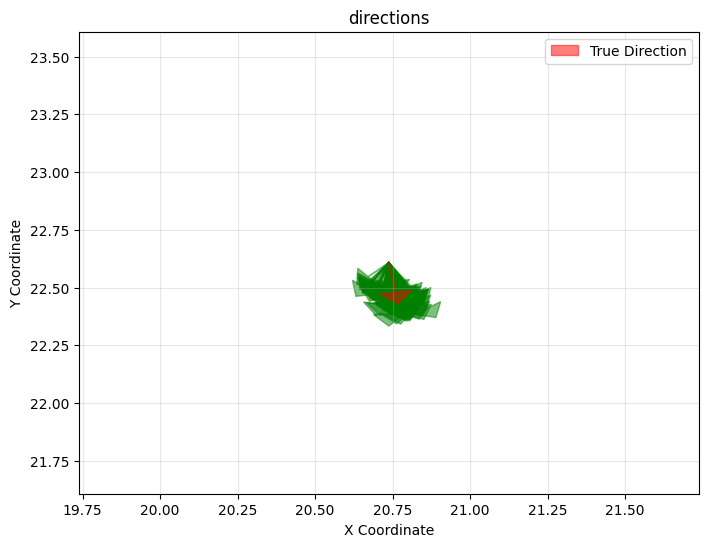

In [69]:
# plot the directions with arrow based on the positions
curr_pos = set_ob[:2]
next_pos = np.array(next_observations)[:,:2]

# Adjust the plot size such that arrow is small and fit in the plot
plt.figure(figsize=(8, 6))
plt.xlim(curr_pos[0]-1, curr_pos[0]+1)
plt.ylim(curr_pos[1]-1, curr_pos[1]+1)
for i in range(next_pos.shape[0]):
    plt.arrow(curr_pos[0], curr_pos[1], next_pos[i,0]-curr_pos[0], next_pos[i,1]-curr_pos[1], head_width=0.1, head_length=0.05, fc='green', ec='green', alpha=0.5)
plt.arrow(curr_pos[0], curr_pos[1], true_direction[0], true_direction[1], head_width=0.1, head_length=0.05, fc='red', ec='red', alpha=0.5, label='True Direction')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.title('directions')
plt.grid(True, alpha=0.3)
plt.show()

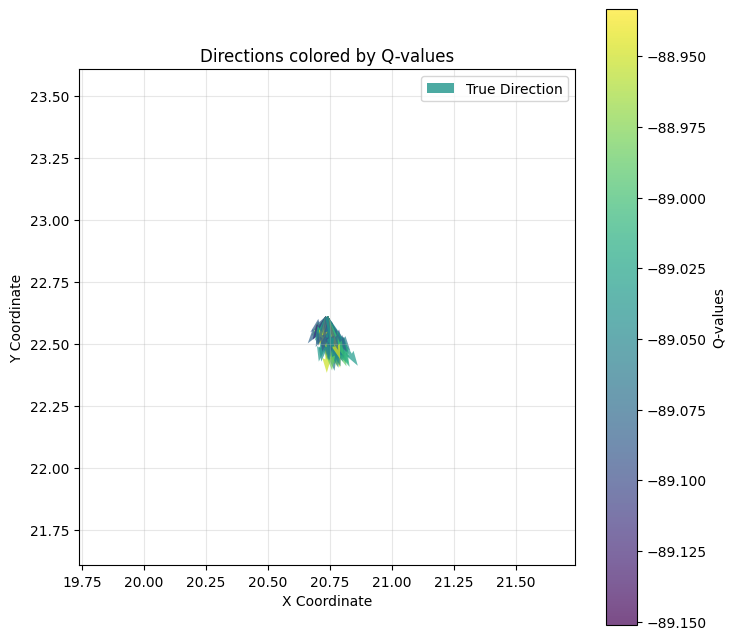

In [70]:
q_vals = np.array(q_vals)
if q_vals.shape[-1] == 2:
    q_vals = q_vals.min(axis=-1)

# plot the directions with arrow based on the positions
curr_pos = set_ob[:2]
next_pos = np.array(next_observations)[:,:2]

# Calculate the direction vectors (dx, dy) for the quiver plot
directions = next_pos - curr_pos
dx = directions[:, 0]
dy = directions[:, 1]

# The Q-values to use for coloring
q_vals_array = np.array(q_vals)

# Adjust the plot size
plt.figure(figsize=(8, 8))

# --- Use plt.quiver for efficient and correct plotting ---
# It takes the origin (curr_pos), the directions (dx, dy), and the color values (q_vals_array)
quiver = plt.quiver(
    [curr_pos[0]] * len(dx),  # Repeat origin x for each arrow
    [curr_pos[1]] * len(dy),  # Repeat origin y for each arrow
    dx,
    dy,
    q_vals_array,            # Use raw Q-values for color, quiver handles normalization
    cmap='viridis',          # The colormap to use
    alpha=0.7,
    angles='xy',             # Ensure arrows point from origin to next_pos
    scale_units='xy',
    scale=1
)

# Add a colorbar to show the mapping of colors to Q-values
cbar = plt.colorbar(quiver)
cbar.set_label('Q-values')

# Plot the 'true direction' arrow separately using quiver
true_color = plt.cm.viridis((true_q_val.min() - q_vals_array.min()) / (q_vals_array.max() - q_vals_array.min()))
plt.quiver(curr_pos[0], curr_pos[1],
           true_direction[0], true_direction[1],
           color=true_color, alpha=0.8,
           angles='xy', scale_units='xy', scale=1,
           width=0.005, headwidth=3, headlength=4,
           label='True Direction')

# Set plot limits and labels
plt.xlim(curr_pos[0] - 1, curr_pos[0] + 1)
plt.ylim(curr_pos[1] - 1, curr_pos[1] + 1)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.title('Directions colored by Q-values')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box') # Make the plot square
plt.show()

### Change of Policy behavior by differing agent position

In [14]:
# load fql model
from agents.fql import get_config as get_fql_config

fql_config = get_fql_config()
fql_agent_class = agents[fql_config['agent_name']]
fql_agent = fql_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    fql_config,
)
fql_actor_fn = supply_rng(fql_agent.sample_actions, rng=jax.random.PRNGKey(np.random.randint(0, 2**32)))

fql_agent_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fql_antmaze-large-navigate-singletask-task2-v0_sd000_20250827_170146"
restore_epoch=1000000
fql_agent = restore_agent(fql_agent, fql_agent_path, restore_epoch)
print(f"FQL agent restored from {fql_agent_path} at epoch {restore_epoch}")

Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fql_antmaze-large-navigate-singletask-task2-v0_sd000_20250827_170146/params_1000000.pkl
FQL agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fql_antmaze-large-navigate-singletask-task2-v0_sd000_20250827_170146 at epoch 1000000


In [35]:
set_x, set_y = 21, 22.7
set_ob = None

# Retriever realistic observation from one of the success cases
for traj in failed_trajs:
    observations = np.array(traj['observation'])

    # Retriever states that are close to the set_x and set_y
    condition = np.where((np.abs(observations[:,0] - set_x) < 0.6) & (np.abs(observations[:,1] - set_y) < 0.6))
    if condition[0].shape[0] > 0:
        # uniform sample from condition
        set_ob = observations[np.random.choice(condition[0])]
        break

if set_ob is not None:
    print("set observation: ", set_ob)
    print("position: ", set_ob[:2])
else:
    print("set observation not found")

q_pos_dim = 15

_, _ = eval_env.reset()
eval_env.set_state(set_ob[:q_pos_dim], set_ob[q_pos_dim:])

# Actor generation
iql_actor_fn = supply_rng(iql_agent.sample_actions, rng=jax.random.PRNGKey(np.random.randint(0, 2**32)))
eval_temperature = 0

action = iql_actor_fn(observations=set_ob, temperature=eval_temperature)
action = np.clip(action, -1, 1)
print("action: ", action)

next_ob, reward, terminated, truncated, info = eval_env.step(action)
next_ob[:2]

true_direction = next_ob[:2] - set_ob[:2]
print("true_direction: ", true_direction)

set observation:  [20.60232387 22.34367856  0.60826435  0.84491757 -0.0869719  -0.02356253
 -0.52725231 -0.53742914  0.54708848  0.52495282 -0.48363924  0.47241688
 -0.66720031 -0.55477567  0.97107861  1.6836313  -1.63961833  0.23083414
 -1.5812468  -0.06163614 -0.60255156 -0.45713563  0.56676548 -2.24700259
 -0.13549918 -1.29199289 -0.84455234  0.5221408  -1.41945119]
position:  [20.60232387 22.34367856]
action:  [ 0.3612737  -0.8707587   0.850831    1.         -0.8849189   0.61776435
 -0.8829667   0.48071873]
true_direction:  [ 0.15365924 -0.16916217]


/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.set_state to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.set_state` for environment variables or `env.get_wrapper_attr('set_state')` that will search the reminding wrappers.
  logger.warn(


In [36]:
# Policy behavior change by different agent position

num_trials = 100
perturbation_range = 2

perturbed_positions = []
next_observations = []
q_vals = []
v_vals = []

for _ in tqdm(range(num_trials)):
    _, _ = eval_env.reset()

    # Perturb the observation (Gaussian noise)
    q_pos, q_vel = set_ob[:q_pos_dim], set_ob[q_pos_dim:]
    pos, rem_q_pos = q_pos[:2], q_pos[2:]

    perturbed_pos = pos + np.random.normal(0, perturbation_range, size=pos.shape)

    ## only consider 18.7 < x < 21 and 0 < y < 25
    if perturbed_pos[0] < 18.7 or perturbed_pos[0] > 21 or perturbed_pos[1] < 0 or perturbed_pos[1] > 25:
        continue

    perturbed_positions.append(perturbed_pos)

    perturbed_ob = np.concatenate([perturbed_pos, rem_q_pos, q_vel]) # Ensure that we are evaluating at the same position, jsut with different pose
    eval_env.set_state(perturbed_ob[:q_pos_dim], perturbed_ob[q_pos_dim:])

    # Get the action
    action = iql_actor_fn(observations=perturbed_ob, temperature=eval_temperature)
    action = np.clip(action, -1, 1)

    next_ob, reward, terminated, truncated, info = eval_env.step(action)
    next_observations.append(next_ob)

    # Compute the Q(s,a) and V(s')
    q_val = iql_agent.network.select('critic')(perturbed_ob, action)
    v_val = iql_agent.network.select('value')(next_ob)
    q_vals.append(q_val)
    v_vals.append(v_val)

q_vals = np.array(q_vals)
v_vals = np.array(v_vals)

# consine similarieis of directions with the true direction
perturbed_directions = np.array(next_observations)[:,:2] - set_ob[:2]
# Calculate angles between perturbed directions and true direction
dot_products = np.dot(perturbed_directions, true_direction)
norms_perturbed = np.linalg.norm(perturbed_directions, axis=1)
norm_true = np.linalg.norm(true_direction)
cosine_values = dot_products / (norms_perturbed * norm_true)
# Clamp cosine values to [-1, 1] to avoid numerical errors
cosine_values = np.clip(cosine_values, -1, 1)
angles = np.arccos(cosine_values)
print("angles (radians): ", angles.mean())
print("angles (degrees): ", np.degrees(angles).mean())
print("max angle: ", angles.max())
print("min angle: ", angles.min())


100%|██████████| 100/100 [00:14<00:00,  6.89it/s]

angles (radians):  1.6173726359335783
angles (degrees):  92.66862593894307
max angle:  3.0901316560942242
min angle:  0.013902384108293394


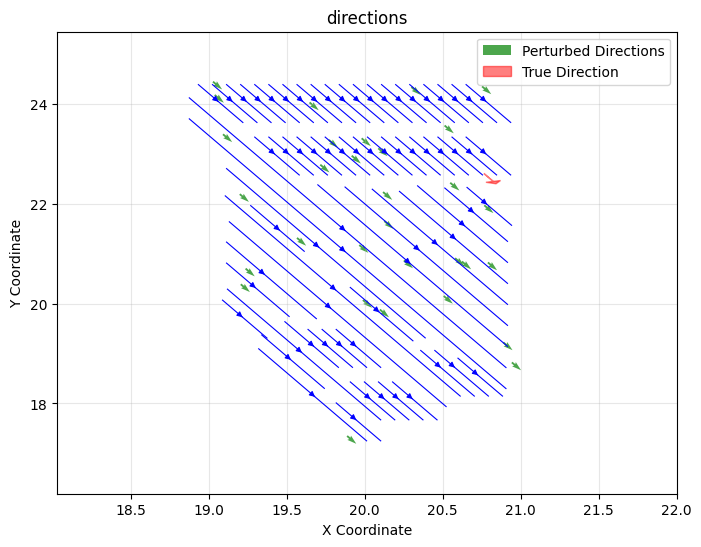

In [31]:
# plot the directions with arrow based on the positions
true_curr_pos = set_ob[:2]

curr_pos = np.array(perturbed_positions)[:,:2]
next_pos = np.array(next_observations)[:,:2]

max_x = np.max(np.concatenate([curr_pos, next_pos], axis=0)[:,0])
min_x = np.min(np.concatenate([curr_pos, next_pos], axis=0)[:,0])
max_y = np.max(np.concatenate([curr_pos, next_pos], axis=0)[:,1])
min_y = np.min(np.concatenate([curr_pos, next_pos], axis=0)[:,1])

# Adjust the plot size such that arrow is small and fit in the plot
plt.figure(figsize=(8, 6))
plt.xlim(min_x-1, max_x+1)
plt.ylim(min_y-1, max_y+1)
# Use quiver plot for better visualization of many arrows
dx = next_pos[:,0] - curr_pos[:,0]
dy = next_pos[:,1] - curr_pos[:,1]
plt.quiver(curr_pos[:,0], curr_pos[:,1], dx, dy, angles='xy', scale_units='xy', scale=1, color='green', alpha=0.7, width=0.003, label='Perturbed Directions')
# Add streamplot for continuous visualization
x_grid = np.linspace(min_x-1, max_x+1, 20)
y_grid = np.linspace(min_y-1, max_y+1, 20)
X, Y = np.meshgrid(x_grid, y_grid)
# Interpolate the direction field
from scipy.interpolate import griddata
U = griddata((curr_pos[:,0], curr_pos[:,1]), dx, (X, Y), method='linear', fill_value=0)
V = griddata((curr_pos[:,0], curr_pos[:,1]), dy, (X, Y), method='linear', fill_value=0)
plt.streamplot(X, Y, U, V, color='blue', density=1.5, linewidth=0.8, arrowsize=0.8)
plt.arrow(true_curr_pos[0], true_curr_pos[1], true_direction[0], true_direction[1], head_width=0.1, head_length=0.05, fc='red', ec='red', alpha=0.5, label='True Direction')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.title('directions')
plt.grid(True, alpha=0.3)
plt.show()

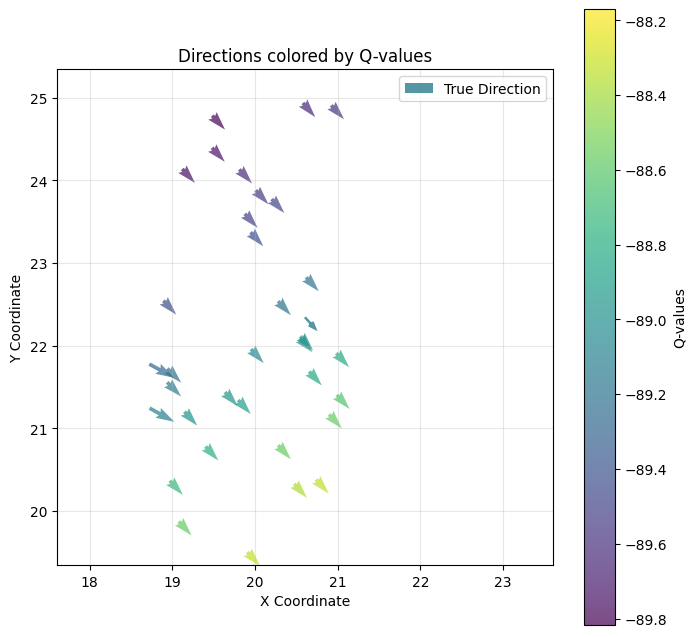

In [40]:

if q_vals.shape[-1] == 2:
    q_vals = q_vals.min(axis=-1)

# plot the directions with arrow based on the positions
true_curr_pos = set_ob[:2]
curr_pos = np.array(perturbed_positions)[:,:2]
next_pos = np.array(next_observations)[:,:2]

# Calculate the direction vectors (dx, dy) for the quiver plot
directions = next_pos - curr_pos
dx = directions[:, 0]
dy = directions[:, 1]

# The Q-values to use for coloring
q_vals_array = np.array(q_vals)

# Adjust the plot size
plt.figure(figsize=(8, 8))

# --- Use plt.quiver for efficient and correct plotting ---
# It takes the origin (curr_pos), the directions (dx, dy), and the color values (q_vals_array)
quiver = plt.quiver(
    curr_pos[:,0],
    curr_pos[:,1],
    dx,
    dy,
    q_vals_array,            # Use raw Q-values for color, quiver handles normalization
    cmap='viridis',          # The colormap to use
    alpha=0.7,
    angles='xy',             # Ensure arrows point from origin to next_pos
    scale_units='xy',
    scale=1
)

# Add a colorbar to show the mapping of colors to Q-values
cbar = plt.colorbar(quiver)
cbar.set_label('Q-values')

# Plot the 'true direction' arrow separately using quiver
true_color = plt.cm.viridis((true_action_q_val.min() - q_vals_array.min()) / (q_vals_array.max() - q_vals_array.min()))
plt.quiver(true_curr_pos[0], true_curr_pos[1],
           true_direction[0], true_direction[1],
           color=true_color, alpha=0.8,
           angles='xy', scale_units='xy', scale=1,
           width=0.005, headwidth=3, headlength=4,
           label='True Direction')

# Set plot limits and labels
plt.xlim(true_curr_pos[0] - 3, true_curr_pos[0] + 3)
plt.ylim(true_curr_pos[1] - 3, true_curr_pos[1] + 3)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.title('Directions colored by Q-values')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box') # Make the plot square
plt.show()

In [218]:
iql_jcb_actor_fn = supply_rng(iql_agent_jcb.sample_actions, rng=jax.random.PRNGKey(np.random.randint(0, 2**32)))

### Change of action by observation dimension

In [210]:
set_x, set_y = 12, 16
set_ob = None

# Retriever realistic observation from one of the success cases
for traj in success_trajs:
    observations = np.array(traj['observation'])

    # Retriever states that are close to the set_x and set_y
    condition = np.where((np.abs(observations[:,0] - set_x) < 0.6) & (np.abs(observations[:,1] - set_y) < 0.6))
    if condition[0].shape[0] > 0:
        # uniform sample from condition
        set_ob = observations[np.random.choice(condition[0])]
        break

if set_ob is not None:
    print("set observation: ", set_ob)
    print("position: ", set_ob[:2])
else:
    print("set observation not found")

q_pos_dim = 15

_, _ = eval_env.reset()
eval_env.set_state(set_ob[:q_pos_dim], set_ob[q_pos_dim:])

# Actor generation
iql_actor_fn = supply_rng(iql_agent.sample_actions, rng=jax.random.PRNGKey(np.random.randint(0, 2**32)))
eval_temperature = 0

action = iql_actor_fn(observations=set_ob, temperature=eval_temperature)
action = np.clip(action, -1, 1)
print("action: ", action)

next_ob, reward, terminated, truncated, info = eval_env.step(action)
next_ob[:2]

true_q_val=iql_agent.network.select('critic')(set_ob, action)
true_v_val=iql_agent.network.select('value')(next_ob)


# Evaluate on the same pertrubed states
traget_ob_dim=5
num_trials = 100
perturbation_range = 0.1

perturbed_values = []
perturbed_obs = []
perturbed_positions = []
# 1. repeat the copy of states for number of trials
for _ in range(num_trials):
    perturbed_value = set_ob[traget_ob_dim] + np.random.normal(0, perturbation_range, size=set_ob[traget_ob_dim].shape)
    perturbed_ob = set_ob.copy()
    perturbed_ob[traget_ob_dim] = perturbed_value
    perturbed_values.append(perturbed_value)
    perturbed_obs.append(perturbed_ob)
    perturbed_positions.append(perturbed_ob[:2])

perturbed_values = np.array(perturbed_values)
perturbed_positions = np.array(perturbed_positions)
perturbed_obs = np.array(perturbed_obs)
perturbed_obs.shape

set observation:  [ 1.21340005e+01  1.54622417e+01  5.07909054e-01  8.44323989e-01
  4.26385733e-03 -5.75782378e-02 -5.32713401e-01  5.62376180e-01
  1.07694824e+00 -1.13081260e-01 -5.65105597e-01 -4.54825691e-01
 -5.20187926e-01  4.64178012e-01  5.18726467e-01 -2.27865869e-01
 -1.40934811e+00 -9.86304754e-01  6.42948972e-01  1.51760967e+00
 -1.14597396e+00 -6.32074867e-01 -2.89230607e+00 -5.53512575e-01
 -8.17610545e-01  2.27192661e+00 -3.41510574e-02  8.82749623e-03
  7.65568250e-02]
position:  [12.13400049 15.46224173]
action:  [-0.95784366 -0.78093994  1.         -1.          0.8619707  -0.57179135
  0.8229958   0.41815054]


/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.set_state to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.set_state` for environment variables or `env.get_wrapper_attr('set_state')` that will search the reminding wrappers.
  logger.warn(


(100, 29)

In [219]:
target_actor_fn=iql_jcb_actor_fn
_, _ = eval_env.reset()
eval_env.set_state(set_ob[:q_pos_dim], set_ob[q_pos_dim:])
action = target_actor_fn(observations=set_ob, temperature=eval_temperature)
action = np.clip(action, -1, 1)
print("action: ", action)

next_ob, reward, terminated, truncated, info = eval_env.step(action)

true_q_val=iql_agent.network.select('critic')(set_ob, action)
true_v_val=iql_agent.network.select('value')(next_ob)
true_direction = next_ob[:2] - set_ob[:2]
print("true_direction: ", true_direction)


# Policy behavior change by different agent position
next_observations = []
q_vals = []
v_vals = []
for i in tqdm(range(num_trials)):
    _, _ = eval_env.reset()

    # Perturb the observation (Gaussian noise)
    eval_env.set_state(perturbed_obs[i][:q_pos_dim], perturbed_obs[i][q_pos_dim:])

    # Get the action
    action = target_actor_fn(observations=perturbed_obs[i], temperature=eval_temperature)
    action = np.clip(action, -1, 1)

    next_ob, reward, terminated, truncated, info = eval_env.step(action)
    next_observations.append(next_ob)

    q_val = iql_agent_a3.network.select('critic')(perturbed_ob, action)
    v_val = iql_agent_a3.network.select('value')(next_ob)
    q_vals.append(q_val)
    v_vals.append(v_val)

# consine similarieis of directions with the true direction
perturbed_directions = np.array(next_observations)[:,:2] - set_ob[:2]
# Calculate angles between perturbed directions and true direction
dot_products = np.dot(perturbed_directions, true_direction)
norms_perturbed = np.linalg.norm(perturbed_directions, axis=1)
norm_true = np.linalg.norm(true_direction)
cosine_values = dot_products / (norms_perturbed * norm_true)
# Clamp cosine values to [-1, 1] to avoid numerical errors
cosine_values = np.clip(cosine_values, -1, 1)
angles = np.arccos(cosine_values)
print("angles (radians): ", angles.mean())
print("angles (degrees): ", np.degrees(angles).mean())
print("max angle: ", angles.max())
print("min angle: ", angles.min())

q_vals = np.array(q_vals)
v_vals = np.array(v_vals)


/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.set_state to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.set_state` for environment variables or `env.get_wrapper_attr('set_state')` that will search the reminding wrappers.
  logger.warn(


action:  [-0.8593396  -0.6135543   0.4544288  -0.8161711   0.8357195  -0.3075433
  0.72807646  0.12066004]
true_direction:  [ 0.0135757  -0.12177346]


100%|██████████| 100/100 [00:14<00:00,  7.12it/s]


angles (radians):  0.3888679618042201
angles (degrees):  22.280492999236312
max angle:  1.2025713740722916
min angle:  0.0012940332973989522


In [220]:
# Q and V values statistics
if q_vals.shape[-1] == 2:
    q_vals_min = q_vals.min(axis=-1)
else:
    q_vals_min = q_vals

if v_vals.shape[-1] == 2:
    v_vals_min = v_vals.min(axis=-1)
else:
    v_vals_min = v_vals

print(true_q_val, (true_q_val.min() < q_vals_min).sum())
print(f"Q statistics: mean: {q_vals_min.mean()}, min: {q_vals_min.min()}, max: {q_vals_min.max()}, std: {q_vals_min.std()}")

print(true_v_val, (true_v_val.min() < v_vals_min).sum())
print(f"V statistics: mean: {v_vals_min.mean()}, min: {v_vals_min.min()}, max: {v_vals_min.max()}, std: {v_vals_min.std()}")

[-92.72275 -92.9333 ] 28
Q statistics: mean: -92.94174194335938, min: -92.98875427246094, max: -92.86997985839844, std: 0.03199991211295128
-92.8112 21
V statistics: mean: -92.94921875, min: -93.20343017578125, max: -92.78272247314453, std: 0.12439297139644623


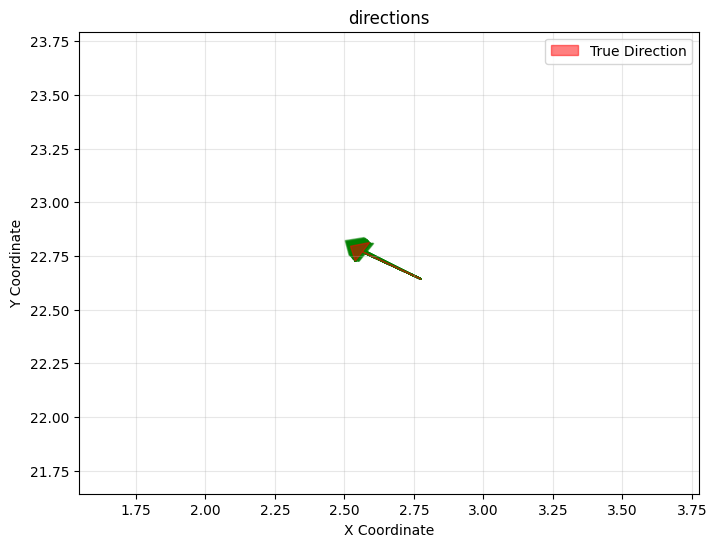

In [192]:
# plot the directions with arrow based on the positions
true_curr_pos = set_ob[:2]

curr_pos = np.array(perturbed_positions)[:,:2]
next_pos = np.array(next_observations)[:,:2]

max_x = np.max(np.concatenate([curr_pos, next_pos], axis=0)[:,0])
min_x = np.min(np.concatenate([curr_pos, next_pos], axis=0)[:,0])
max_y = np.max(np.concatenate([curr_pos, next_pos], axis=0)[:,1])
min_y = np.min(np.concatenate([curr_pos, next_pos], axis=0)[:,1])

# Adjust the plot size such that arrow is small and fit in the plot
plt.figure(figsize=(8, 6))
plt.xlim(min_x-1, max_x+1)
plt.ylim(min_y-1, max_y+1)
for i in range(next_pos.shape[0]):
        plt.arrow(curr_pos[i,0], curr_pos[i,1], next_pos[i,0]-curr_pos[i,0], next_pos[i,1]-curr_pos[i,1], head_width=0.1, head_length=0.05, fc='green', ec='green', alpha=0.5)
plt.arrow(true_curr_pos[0], true_curr_pos[1], true_direction[0], true_direction[1], head_width=0.1, head_length=0.05, fc='red', ec='red', alpha=0.5, label='True Direction')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.title('directions')
plt.grid(True, alpha=0.3)
plt.show()

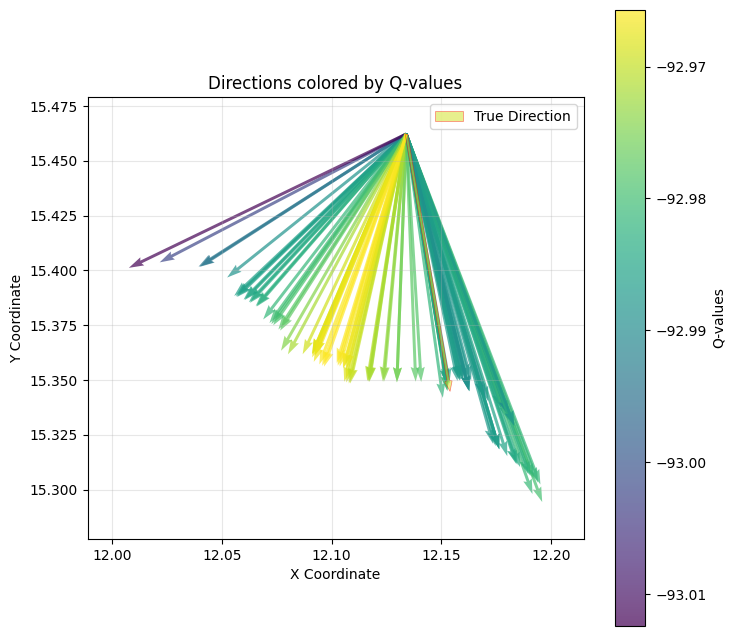

In [213]:
q_vals = np.array(q_vals)
if q_vals.shape[-1] == 2:
    q_vals = q_vals.min(axis=-1)

# plot the directions with arrow based on the positions
curr_pos = set_ob[:2]
next_pos = np.array(next_observations)[:,:2]

# Calculate the direction vectors (dx, dy) for the quiver plot
directions = next_pos - curr_pos
dx = directions[:, 0]
dy = directions[:, 1]

# The Q-values to use for coloring
q_vals_array = np.array(q_vals)

# Adjust the plot size
plt.figure(figsize=(8, 8))

# --- Use plt.quiver for efficient and correct plotting ---
# It takes the origin (curr_pos), the directions (dx, dy), and the color values (q_vals_array)
quiver = plt.quiver(
    [curr_pos[0]] * len(dx),  # Repeat origin x for each arrow
    [curr_pos[1]] * len(dy),  # Repeat origin y for each arrow
    dx,
    dy,
    q_vals_array,            # Use raw Q-values for color, quiver handles normalization
    cmap='viridis',          # The colormap to use
    alpha=0.7,
    angles='xy',             # Ensure arrows point from origin to next_pos
    scale_units='xy',
    scale=1
)

# Add a colorbar to show the mapping of colors to Q-values
cbar = plt.colorbar(quiver)
cbar.set_label('Q-values')

# Plot the 'true direction' arrow separately using quiver (with red edges to be shown clear, edge width )
true_color = plt.cm.viridis((true_q_val.min() - q_vals_array.min()) / (q_vals_array.max() - q_vals_array.min()))
plt.quiver(curr_pos[0], curr_pos[1],
           true_direction[0], true_direction[1],
           color=true_color, alpha=0.5, edgecolor='red', linewidth=0.5,
           angles='xy', scale_units='xy', scale=1,
           width=0.005, headwidth=3, headlength=4,
           label='True Direction')

# Set plot limits and labels
# set plot limits to be 10% larger than the max y and min
max_x = np.max(np.concatenate([curr_pos.reshape(1, -1), next_pos], axis=0)[:,0])
min_x = np.min(np.concatenate([curr_pos.reshape(1, -1), next_pos], axis=0)[:,0])
max_y = np.max(np.concatenate([curr_pos.reshape(1, -1), next_pos], axis=0)[:,1])
min_y = np.min(np.concatenate([curr_pos.reshape(1, -1), next_pos], axis=0)[:,1])
plt.xlim(min_x - 0.1 * (max_x - min_x), max_x + 0.1 * (max_x - min_x))
plt.ylim(min_y - 0.1 * (max_y - min_y), max_y + 0.1 * (max_y - min_y))
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.title('Directions colored by Q-values')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box') # Make the plot square
plt.show()

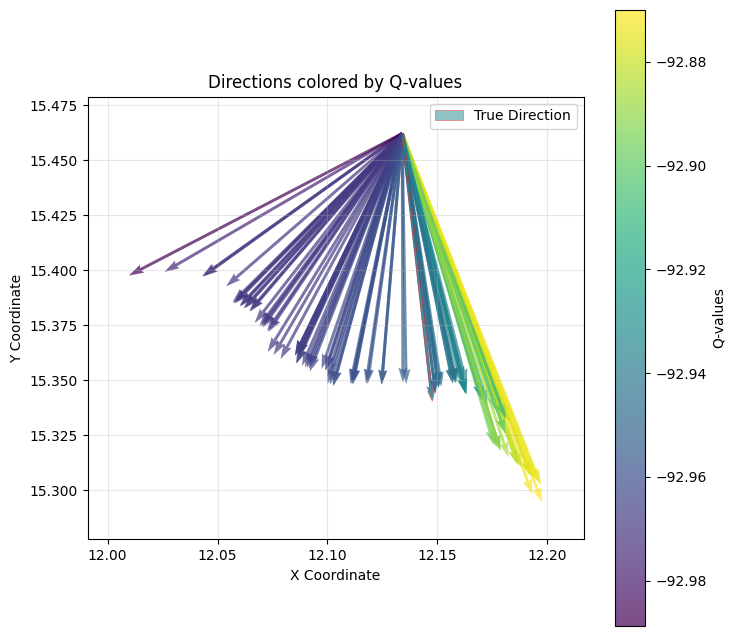

In [221]:
q_vals = np.array(q_vals)
if q_vals.shape[-1] == 2:
    q_vals = q_vals.min(axis=-1)

# plot the directions with arrow based on the positions
curr_pos = set_ob[:2]
next_pos = np.array(next_observations)[:,:2]

# Calculate the direction vectors (dx, dy) for the quiver plot
directions = next_pos - curr_pos
dx = directions[:, 0]
dy = directions[:, 1]

# The Q-values to use for coloring
q_vals_array = np.array(q_vals)

# Adjust the plot size
plt.figure(figsize=(8, 8))

# --- Use plt.quiver for efficient and correct plotting ---
# It takes the origin (curr_pos), the directions (dx, dy), and the color values (q_vals_array)
quiver = plt.quiver(
    [curr_pos[0]] * len(dx),  # Repeat origin x for each arrow
    [curr_pos[1]] * len(dy),  # Repeat origin y for each arrow
    dx,
    dy,
    q_vals_array,            # Use raw Q-values for color, quiver handles normalization
    cmap='viridis',          # The colormap to use
    alpha=0.7,
    angles='xy',             # Ensure arrows point from origin to next_pos
    scale_units='xy',
    scale=1
)

# Add a colorbar to show the mapping of colors to Q-values
cbar = plt.colorbar(quiver)
cbar.set_label('Q-values')

# Plot the 'true direction' arrow separately using quiver (with red edges to be shown clear, edge width )
true_color = plt.cm.viridis((true_q_val.min() - q_vals_array.min()) / (q_vals_array.max() - q_vals_array.min()))
plt.quiver(curr_pos[0], curr_pos[1],
           true_direction[0], true_direction[1],
           color=true_color, alpha=0.5, edgecolor='red', linewidth=0.5,
           angles='xy', scale_units='xy', scale=1,
           width=0.005, headwidth=3, headlength=4,
           label='True Direction')

# Set plot limits and labels
# set plot limits to be 10% larger than the max y and min
max_x = np.max(np.concatenate([curr_pos.reshape(1, -1), next_pos], axis=0)[:,0])
min_x = np.min(np.concatenate([curr_pos.reshape(1, -1), next_pos], axis=0)[:,0])
max_y = np.max(np.concatenate([curr_pos.reshape(1, -1), next_pos], axis=0)[:,1])
min_y = np.min(np.concatenate([curr_pos.reshape(1, -1), next_pos], axis=0)[:,1])
plt.xlim(min_x - 0.1 * (max_x - min_x), max_x + 0.1 * (max_x - min_x))
plt.ylim(min_y - 0.1 * (max_y - min_y), max_y + 0.1 * (max_y - min_y))
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.title('Directions colored by Q-values')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box') # Make the plot square
plt.show()

In [21]:
import copy

def agent_behavior_over_ob_dim(actor_fn, eval_env, set_ob, q_pos_dim, num_trials, perturbation_range):
    # Policy behavior change by different agent position
    rets = {}

    _, _ = eval_env.reset()
    eval_env.set_state(set_ob[:q_pos_dim], set_ob[q_pos_dim:])
    eval_temperature = 0

    action = actor_fn(observations=set_ob, temperature=eval_temperature)
    action = np.clip(action, -1, 1)

    next_ob, reward, terminated, truncated, info = eval_env.step(action)
    true_direction = next_ob[:2] - set_ob[:2]
    

    for target_ob_dim in tqdm(range(set_ob.shape[0])):
        perturbed_positions = []
        next_observations = []

        for _ in range(num_trials):
            _, _ = eval_env.reset()

            perturbed_ob = copy.deepcopy(set_ob)

            # Perturb the observation (Gaussian noise)
            perturbed_ob[target_ob_dim] = perturbed_ob[target_ob_dim] + np.random.normal(0, perturbation_range, size=perturbed_ob[target_ob_dim].shape)
            perturbed_positions.append(perturbed_ob[:2])
            eval_env.set_state(perturbed_ob[:q_pos_dim], perturbed_ob[q_pos_dim:])

            # Get the action
            action = actor_fn(observations=perturbed_ob, temperature=eval_temperature)
            action = np.clip(action, -1, 1)

            next_ob, reward, terminated, truncated, info = eval_env.step(action)
            next_observations.append(next_ob)

        # consine similarieis of directions with the true direction
        perturbed_directions = np.array(next_observations)[:,:2] - np.array(perturbed_positions)[:,:2]
        # Calculate angles between perturbed directions and true direction
        dot_products = np.dot(perturbed_directions, true_direction)
        norms_perturbed = np.linalg.norm(perturbed_directions, axis=1)
        norm_true = np.linalg.norm(true_direction)
        cosine_values = dot_products / (norms_perturbed * norm_true)
        # Clamp cosine values to [-1, 1] to avoid numerical errors
        cosine_values = np.clip(cosine_values, -1, 1)
        angles = np.arccos(cosine_values)

        rets[target_ob_dim] = {
            "perturbed_positions": np.array(perturbed_positions),
            "next_observations": np.array(next_observations),
            "perturbed_directions": perturbed_directions,
            "angles": angles,
            "true_direction": true_direction,
        }
    return rets

print(set_ob)

[ 2.05755150e+01  2.25615895e+01  4.69846773e-01  9.67955200e-01
  2.39905490e-03 -6.07641823e-02 -2.43648700e-01 -1.16966560e-02
  1.02055409e+00 -9.17198956e-02 -5.22638786e-01 -4.44708998e-01
 -5.03812529e-01 -5.25002631e-01  4.40625793e-01  4.61599393e-01
 -2.91745557e+00  1.43965890e+00  7.99995763e-01 -1.11892750e+00
  1.42596185e+00  4.67478407e+00  4.09738905e+00 -5.38160788e+00
 -2.75708306e-02 -6.29543492e+00  1.10483204e+00  1.84682780e-03
  7.95899776e-01]


In [22]:
results = agent_behavior_over_ob_dim(
    actor_fn=iql_actor_fn,
    eval_env=eval_env,
    set_ob=copy.deepcopy(set_ob),
    q_pos_dim=15,
    num_trials=100,
    perturbation_range=0.1
)

100%|██████████| 29/29 [00:09<00:00,  3.06it/s]


In [ ]:
avg_angles = []
true_curr_pos = set_ob[:2]

for dim in results.keys():
    # plot the directions with arrow based on the positions

    curr_pos = np.array(results[dim]['perturbed_positions'])[:,:2]
    next_pos = np.array(results[dim]['next_observations'])[:,:2]
    true_direction = results[dim]['true_direction']

    # Adjust the plot size such that arrow is small and fit in the plot
    plt.figure(figsize=(8, 6))
    for i in range(next_pos.shape[0]):
        plt.arrow(curr_pos[i,0], curr_pos[i,1], next_pos[i,0]-curr_pos[i,0], next_pos[i,1]-curr_pos[i,1], head_width=0.1, head_length=0.05, fc='green', ec='green', alpha=0.5)
    plt.arrow(true_curr_pos[0], true_curr_pos[1], true_direction[0], true_direction[1], head_width=0.1, head_length=0.05, fc='red', ec='red', alpha=0.5, label='True Direction')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.title('directions')
    plt.grid(True, alpha=0.3)
    plt.show()
    plt.clf()


    if dim == 0 or dim == 1:
        continue
    
    avg_angles.append(results[dim]['angles'].mean())

max_angle_idx = np.argsort(avg_angles)[::-1] + 2
max_angle_idx

In [24]:
def sort_ob_dim_by_angles(results):
    avg_angles = []

    for dim in results.keys():
        if dim == 0 or dim == 1:
            continue
        
        avg_angles.append(results[dim]['angles'].mean())

    max_angle_idx = np.argsort(avg_angles)[::-1] + 2
    max_angle_idx
    return max_angle_idx



for noise_range in np.arange(0.01, 0.1, 0.01):
    results = agent_behavior_over_ob_dim(
        actor_fn=iql_actor_fn,
        eval_env=eval_env,
        set_ob=set_ob,
        q_pos_dim=15,
        num_trials=100,
        perturbation_range=noise_range
    )
    max_angle_idx = sort_ob_dim_by_angles(results)
    print(noise_range, max_angle_idx)

100%|██████████| 29/29 [00:09<00:00,  3.13it/s]


0.01 [ 5  2  4 12 15  9 13  6  8  3 11 16 27 14 10 19 23 25  7 21 18 17 28 20
 24 26 22]


 45%|████▍     | 13/29 [00:04<00:05,  3.10it/s]


KeyboardInterrupt: 

In [85]:
import jax.numpy as jnp

# Sample batch from training dataset
batch_size = 10000
samples = train_dataset.sample(batch_size)

100%|██████████| 10000/10000 [00:10<00:00, 982.76it/s]
/tmp/ipykernel_2264601/870451866.py:110: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


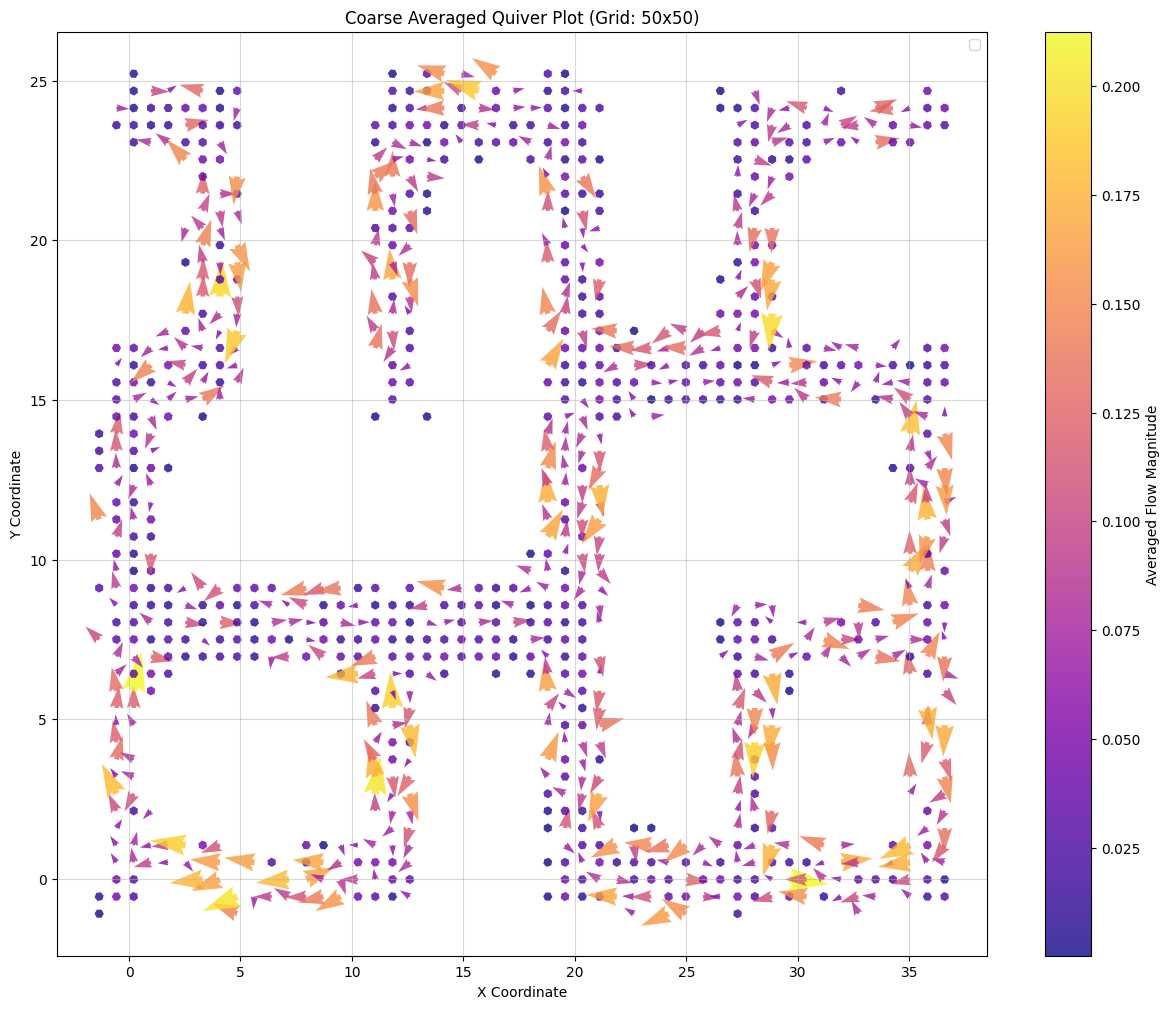

In [78]:
# Generate flow field visualization using training dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

positions = []
flows = []

for obs in tqdm(samples['observations']):
    # Set environment to this state
    eval_env.set_state(obs[:15], obs[15:])
    
    # Get current position (assuming first 2 dimensions are x, y coordinates)
    current_pos = obs[:2]
    
    # Generate action using IQL actor
    action = fql_actor_fn(obs)
    
    # Step environment to get next state
    next_obs, _, _, _, _ = eval_env.step(action)
    next_pos = next_obs[:2]
    
    # Calculate flow vector
    flow = next_pos - current_pos
    
    positions.append(current_pos)
    flows.append(flow)

positions = np.array(positions)
flows = np.array(flows)

# Create grid for streamplot
x_min, x_max = positions[:, 0].min(), positions[:, 0].max()
y_min, y_max = positions[:, 1].min(), positions[:, 1].max()

# Create a coarser grid and average flows within each grid cell
coarse_grid_size = 50  # Much smaller than 50
x_coarse = np.linspace(x_min, x_max, coarse_grid_size)
y_coarse = np.linspace(y_min, y_max, coarse_grid_size)
X_coarse, Y_coarse = np.meshgrid(x_coarse, y_coarse)

# Function to average flows within each grid cell
def average_flows_in_cells(positions, flows, x_edges, y_edges):
    """Average flows within each grid cell"""
    U_avg = np.zeros((len(y_edges)-1, len(x_edges)-1))
    V_avg = np.zeros((len(y_edges)-1, len(x_edges)-1))
    counts = np.zeros((len(y_edges)-1, len(x_edges)-1))
    
    for i, (pos, flow) in enumerate(zip(positions, flows)):
        # Find which grid cell this position belongs to
        x_idx = np.digitize(pos[0], x_edges) - 1
        y_idx = np.digitize(pos[1], y_edges) - 1
        
        # Check bounds
        if 0 <= x_idx < len(x_edges)-1 and 0 <= y_idx < len(y_edges)-1:
            U_avg[y_idx, x_idx] += flow[0]
            V_avg[y_idx, x_idx] += flow[1]
            counts[y_idx, x_idx] += 1
    
    # Avoid division by zero
    counts[counts == 0] = 1
    U_avg /= counts
    V_avg /= counts
    
    return U_avg, V_avg, counts

# Create edges for digitization
x_edges = np.linspace(x_min, x_max, coarse_grid_size + 1)
y_edges = np.linspace(y_min, y_max, coarse_grid_size + 1)

# Average flows in each cell
U_avg, V_avg, counts = average_flows_in_cells(positions, flows, x_edges, y_edges)

# Create center points for each grid cell
X_centers = (x_edges[:-1] + x_edges[1:]) / 2
Y_centers = (y_edges[:-1] + y_edges[1:]) / 2
X_centers_grid, Y_centers_grid = np.meshgrid(X_centers, Y_centers)

# Create mask for cells with insufficient data
min_samples_threshold = 2  # Minimum samples per cell
mask_coarse = counts < min_samples_threshold

# Apply mask
U_masked_coarse = np.ma.masked_where(mask_coarse, U_avg)
V_masked_coarse = np.ma.masked_where(mask_coarse, V_avg)

# Plot coarse averaged quiver
plt.figure(figsize=(15, 12))

# Calculate flow magnitudes for the averaged flows
flow_magnitudes_coarse = np.sqrt(U_avg**2 + V_avg**2)
flow_magnitudes_coarse_masked = np.ma.masked_where(mask_coarse, flow_magnitudes_coarse)

# Create quiver plot with averaged flows
quiver = plt.quiver(X_centers_grid, Y_centers_grid, 
                   U_masked_coarse, V_masked_coarse,
                   flow_magnitudes_coarse_masked,
                   cmap='plasma',
                   scale=5.0,
                   width=0.01,
                   alpha=0.8)

# Add colorbar
cbar = plt.colorbar(quiver)
cbar.set_label('Averaged Flow Magnitude')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Coarse Averaged Quiver Plot (Grid: {coarse_grid_size}x{coarse_grid_size})')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

100%|██████████| 10000/10000 [00:16<00:00, 605.04it/s]
/tmp/ipykernel_2001023/3004289906.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


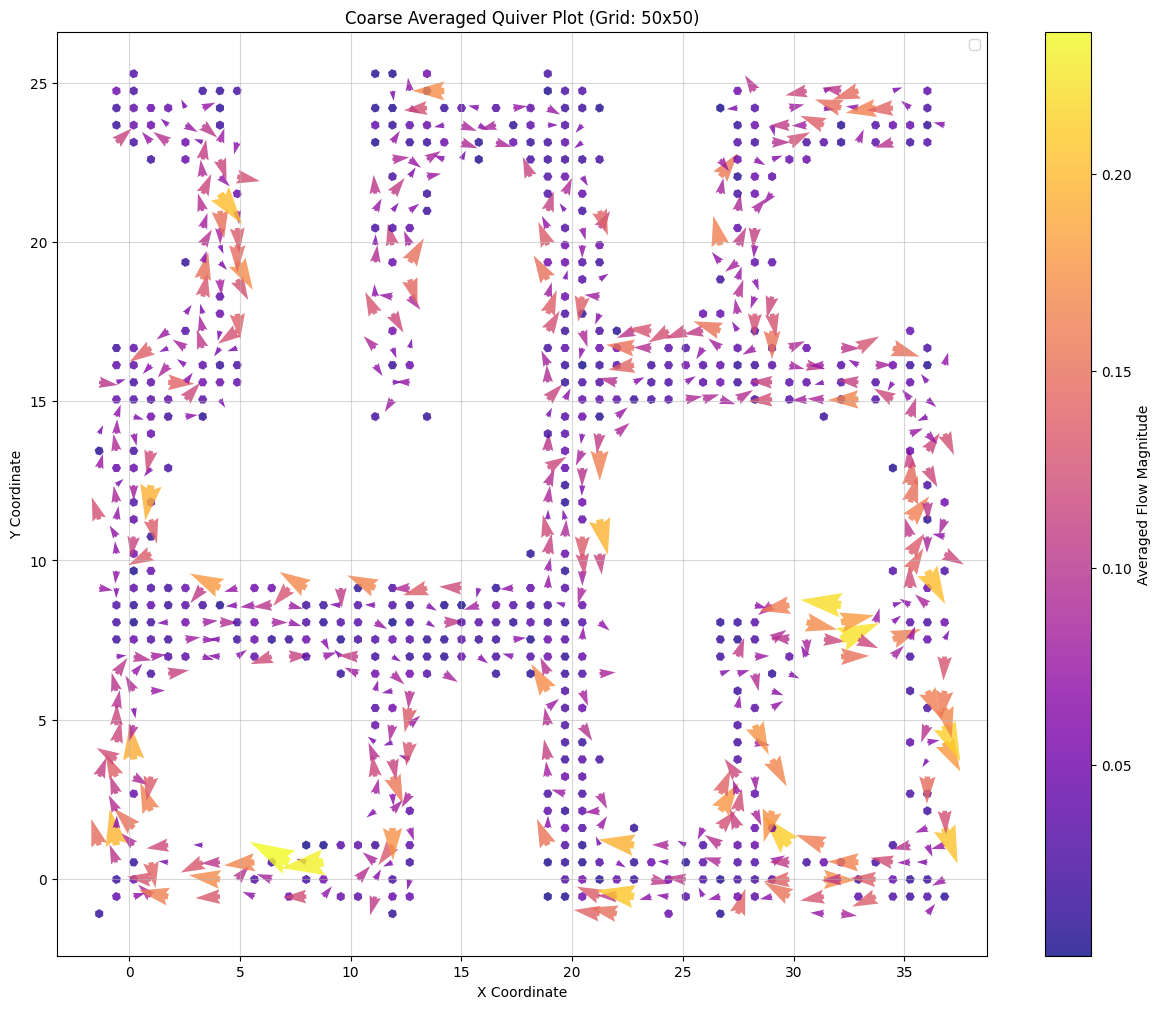

In [69]:
# Generate flow field visualization using training dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Extract positions and generate flow field
positions = []
flows = []

traget_dim = 6

for obs in tqdm(samples['observations']):
    # Set environment to this state
    obs[traget_dim] = obs[traget_dim] + np.random.normal(0, 0.1, size=obs[traget_dim].shape)
    eval_env.set_state(obs[:15], obs[15:])
    
    # Get current position (assuming first 2 dimensions are x, y coordinates)
    current_pos = obs[:2]
    
    # Generate action using IQL actor
    action = fql_actor_fn(obs)
    
    # Step environment to get next state
    next_obs, _, _, _, _ = eval_env.step(action)
    next_pos = next_obs[:2]
    
    # Calculate flow vector
    flow = next_pos - current_pos
    
    positions.append(current_pos)
    flows.append(flow)

positions = np.array(positions)
flows = np.array(flows)

# Create grid for streamplot
x_min, x_max = positions[:, 0].min(), positions[:, 0].max()
y_min, y_max = positions[:, 1].min(), positions[:, 1].max()

coarse_grid_size = 50  # Much smaller than 50
x_coarse = np.linspace(x_min, x_max, coarse_grid_size)
y_coarse = np.linspace(y_min, y_max, coarse_grid_size)
X_coarse, Y_coarse = np.meshgrid(x_coarse, y_coarse)

# Function to average flows within each grid cell
def average_flows_in_cells(positions, flows, x_edges, y_edges):
    """Average flows within each grid cell"""
    U_avg = np.zeros((len(y_edges)-1, len(x_edges)-1))
    V_avg = np.zeros((len(y_edges)-1, len(x_edges)-1))
    counts = np.zeros((len(y_edges)-1, len(x_edges)-1))
    
    for i, (pos, flow) in enumerate(zip(positions, flows)):
        # Find which grid cell this position belongs to
        x_idx = np.digitize(pos[0], x_edges) - 1
        y_idx = np.digitize(pos[1], y_edges) - 1
        
        # Check bounds
        if 0 <= x_idx < len(x_edges)-1 and 0 <= y_idx < len(y_edges)-1:
            U_avg[y_idx, x_idx] += flow[0]
            V_avg[y_idx, x_idx] += flow[1]
            counts[y_idx, x_idx] += 1
    
    # Avoid division by zero
    counts[counts == 0] = 1
    U_avg /= counts
    V_avg /= counts
    
    return U_avg, V_avg, counts

# Create edges for digitization
x_edges = np.linspace(x_min, x_max, coarse_grid_size + 1)
y_edges = np.linspace(y_min, y_max, coarse_grid_size + 1)

# Average flows in each cell
U_avg, V_avg, counts = average_flows_in_cells(positions, flows, x_edges, y_edges)

# Create center points for each grid cell
X_centers = (x_edges[:-1] + x_edges[1:]) / 2
Y_centers = (y_edges[:-1] + y_edges[1:]) / 2
X_centers_grid, Y_centers_grid = np.meshgrid(X_centers, Y_centers)

# Create mask for cells with insufficient data
min_samples_threshold = 2  # Minimum samples per cell
mask_coarse = counts < min_samples_threshold

# Apply mask
U_masked_coarse = np.ma.masked_where(mask_coarse, U_avg)
V_masked_coarse = np.ma.masked_where(mask_coarse, V_avg)

# Plot coarse averaged quiver
plt.figure(figsize=(15, 12))

# Calculate flow magnitudes for the averaged flows
flow_magnitudes_coarse = np.sqrt(U_avg**2 + V_avg**2)
flow_magnitudes_coarse_masked = np.ma.masked_where(mask_coarse, flow_magnitudes_coarse)

# Create quiver plot with averaged flows
quiver = plt.quiver(X_centers_grid, Y_centers_grid, 
                   U_masked_coarse, V_masked_coarse,
                   flow_magnitudes_coarse_masked,
                   cmap='plasma',
                   scale=5.0,
                   width=0.01,
                   alpha=0.8)

# Add colorbar
cbar = plt.colorbar(quiver)
cbar.set_label('Averaged Flow Magnitude')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Coarse Averaged Quiver Plot (Grid: {coarse_grid_size}x{coarse_grid_size})')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

100%|██████████| 10000/10000 [01:01<00:00, 163.55it/s]
/tmp/ipykernel_2536318/3823470294.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


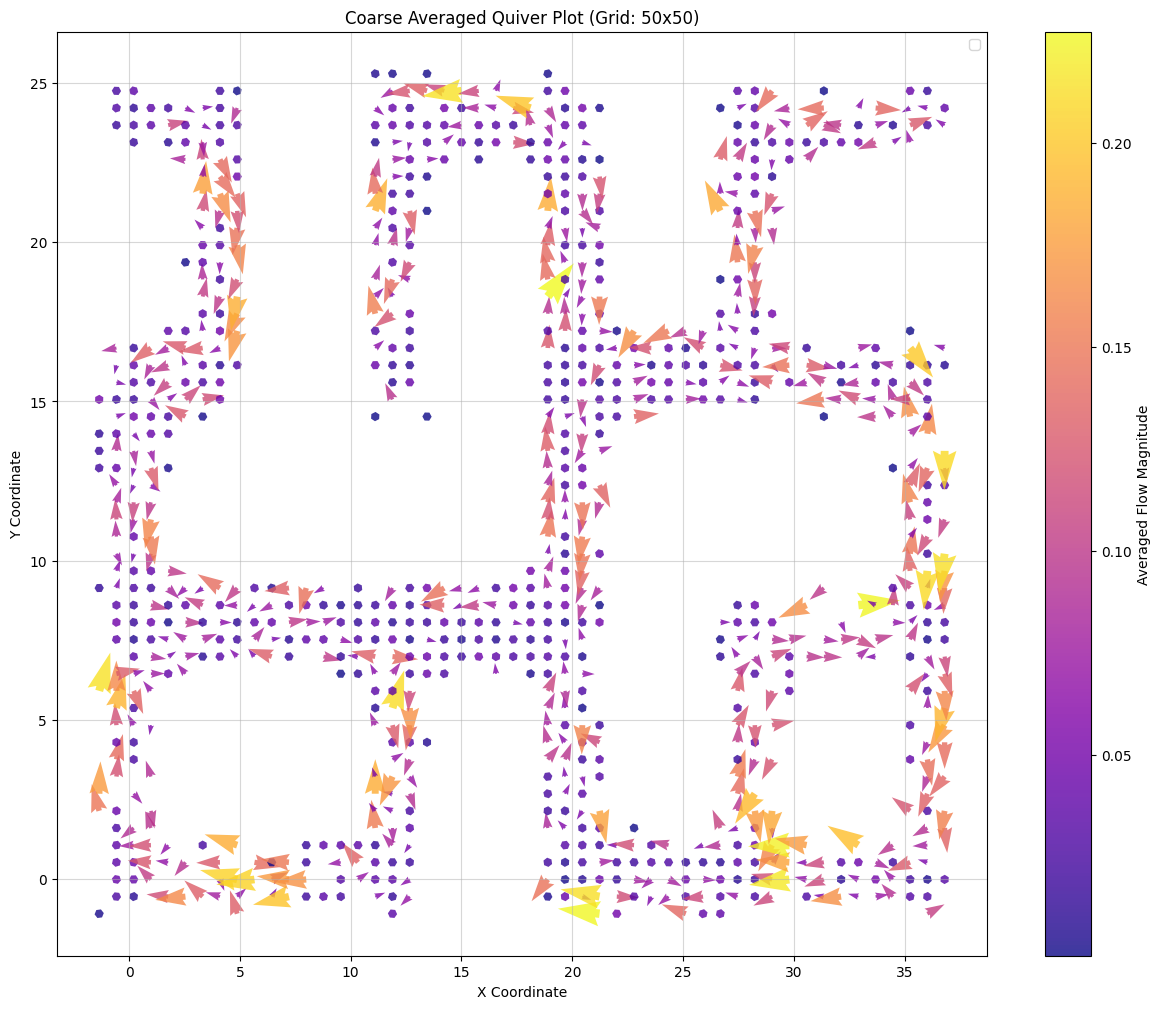

In [86]:
# Generate flow field visualization using training dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


# Extract positions and generate flow field
positions = []
flows = []

traget_dim = 4

for obs in tqdm(samples['observations']):
    # Set environment to this state
    obs[traget_dim] = obs[traget_dim] + np.random.normal(0, 0.01, size=obs[traget_dim].shape)
    eval_env.set_state(obs[:15], obs[15:])
    
    # Get current position (assuming first 2 dimensions are x, y coordinates)
    current_pos = obs[:2]
    
    # Generate action using IQL actor
    action = iql_actor_fn(obs)
    
    # Step environment to get next state
    next_obs, _, _, _, _ = eval_env.step(action)
    next_pos = next_obs[:2]
    
    # Calculate flow vector
    flow = next_pos - current_pos
    
    positions.append(current_pos)
    flows.append(flow)

positions = np.array(positions)
flows = np.array(flows)

# Create grid for streamplot
x_min, x_max = positions[:, 0].min(), positions[:, 0].max()
y_min, y_max = positions[:, 1].min(), positions[:, 1].max()

coarse_grid_size = 50  # Much smaller than 50
x_coarse = np.linspace(x_min, x_max, coarse_grid_size)
y_coarse = np.linspace(y_min, y_max, coarse_grid_size)
X_coarse, Y_coarse = np.meshgrid(x_coarse, y_coarse)

# Function to average flows within each grid cell
def average_flows_in_cells(positions, flows, x_edges, y_edges):
    """Average flows within each grid cell"""
    U_avg = np.zeros((len(y_edges)-1, len(x_edges)-1))
    V_avg = np.zeros((len(y_edges)-1, len(x_edges)-1))
    counts = np.zeros((len(y_edges)-1, len(x_edges)-1))
    
    for i, (pos, flow) in enumerate(zip(positions, flows)):
        # Find which grid cell this position belongs to
        x_idx = np.digitize(pos[0], x_edges) - 1
        y_idx = np.digitize(pos[1], y_edges) - 1
        
        # Check bounds
        if 0 <= x_idx < len(x_edges)-1 and 0 <= y_idx < len(y_edges)-1:
            U_avg[y_idx, x_idx] += flow[0]
            V_avg[y_idx, x_idx] += flow[1]
            counts[y_idx, x_idx] += 1
    
    # Avoid division by zero
    counts[counts == 0] = 1
    U_avg /= counts
    V_avg /= counts
    
    return U_avg, V_avg, counts

# Create edges for digitization
x_edges = np.linspace(x_min, x_max, coarse_grid_size + 1)
y_edges = np.linspace(y_min, y_max, coarse_grid_size + 1)

# Average flows in each cell
U_avg, V_avg, counts = average_flows_in_cells(positions, flows, x_edges, y_edges)

# Create center points for each grid cell
X_centers = (x_edges[:-1] + x_edges[1:]) / 2
Y_centers = (y_edges[:-1] + y_edges[1:]) / 2
X_centers_grid, Y_centers_grid = np.meshgrid(X_centers, Y_centers)

# Create mask for cells with insufficient data
min_samples_threshold = 2  # Minimum samples per cell
mask_coarse = counts < min_samples_threshold

# Apply mask
U_masked_coarse = np.ma.masked_where(mask_coarse, U_avg)
V_masked_coarse = np.ma.masked_where(mask_coarse, V_avg)

# Plot coarse averaged quiver
plt.figure(figsize=(15, 12))

# Calculate flow magnitudes for the averaged flows
flow_magnitudes_coarse = np.sqrt(U_avg**2 + V_avg**2)
flow_magnitudes_coarse_masked = np.ma.masked_where(mask_coarse, flow_magnitudes_coarse)

# Create quiver plot with averaged flows
quiver = plt.quiver(X_centers_grid, Y_centers_grid, 
                   U_masked_coarse, V_masked_coarse,
                   flow_magnitudes_coarse_masked,
                   cmap='plasma',
                   scale=5.0,
                   width=0.01,
                   alpha=0.8)

# Add colorbar
cbar = plt.colorbar(quiver)
cbar.set_label('Averaged Flow Magnitude')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Coarse Averaged Quiver Plot (Grid: {coarse_grid_size}x{coarse_grid_size})')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [27]:
import jax.numpy as jnp

# Sample batch from training dataset
batch_size = 10000
samples = train_dataset.sample(batch_size)
batch_states = samples['observations']

Computing policy gradients...


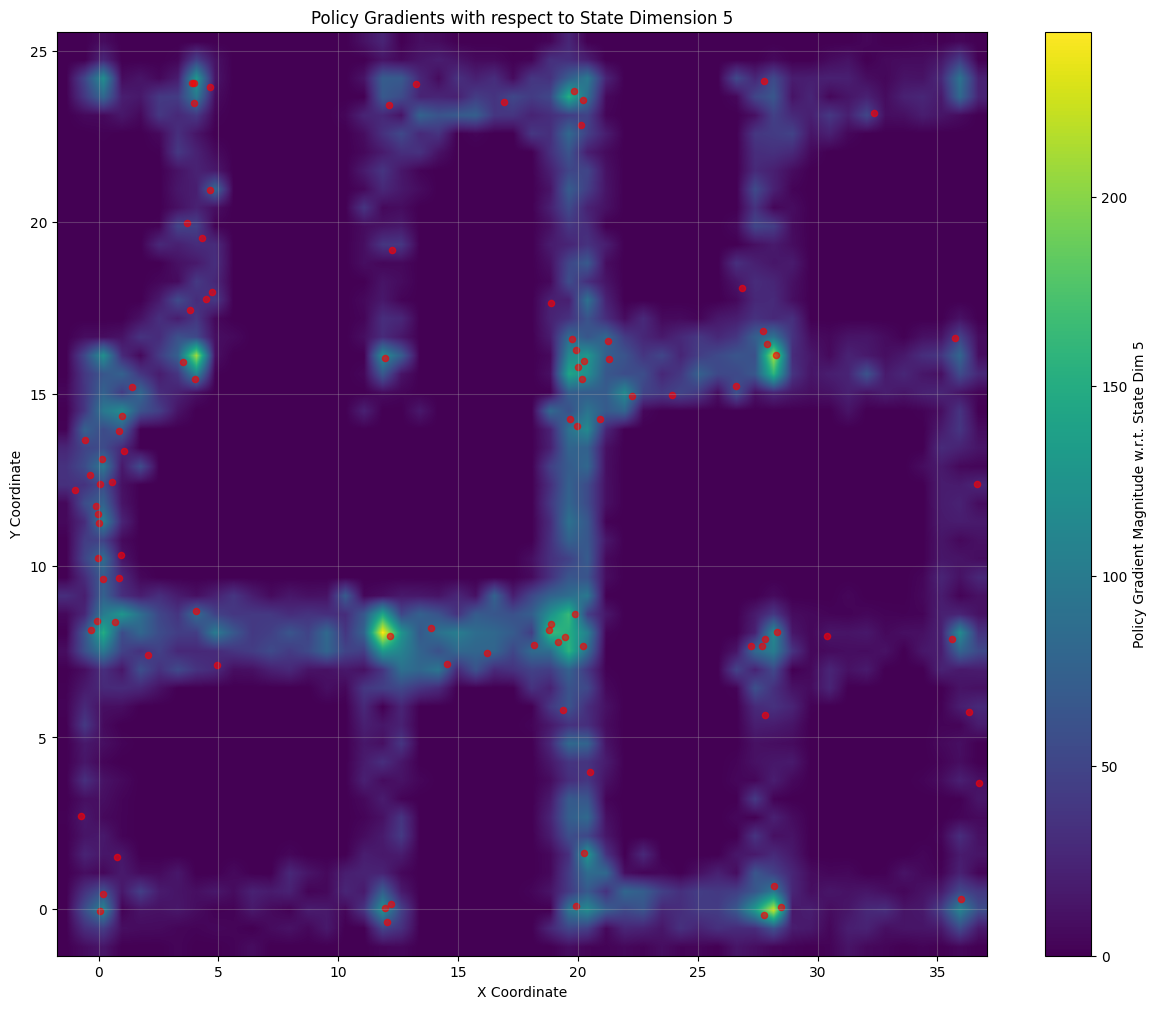

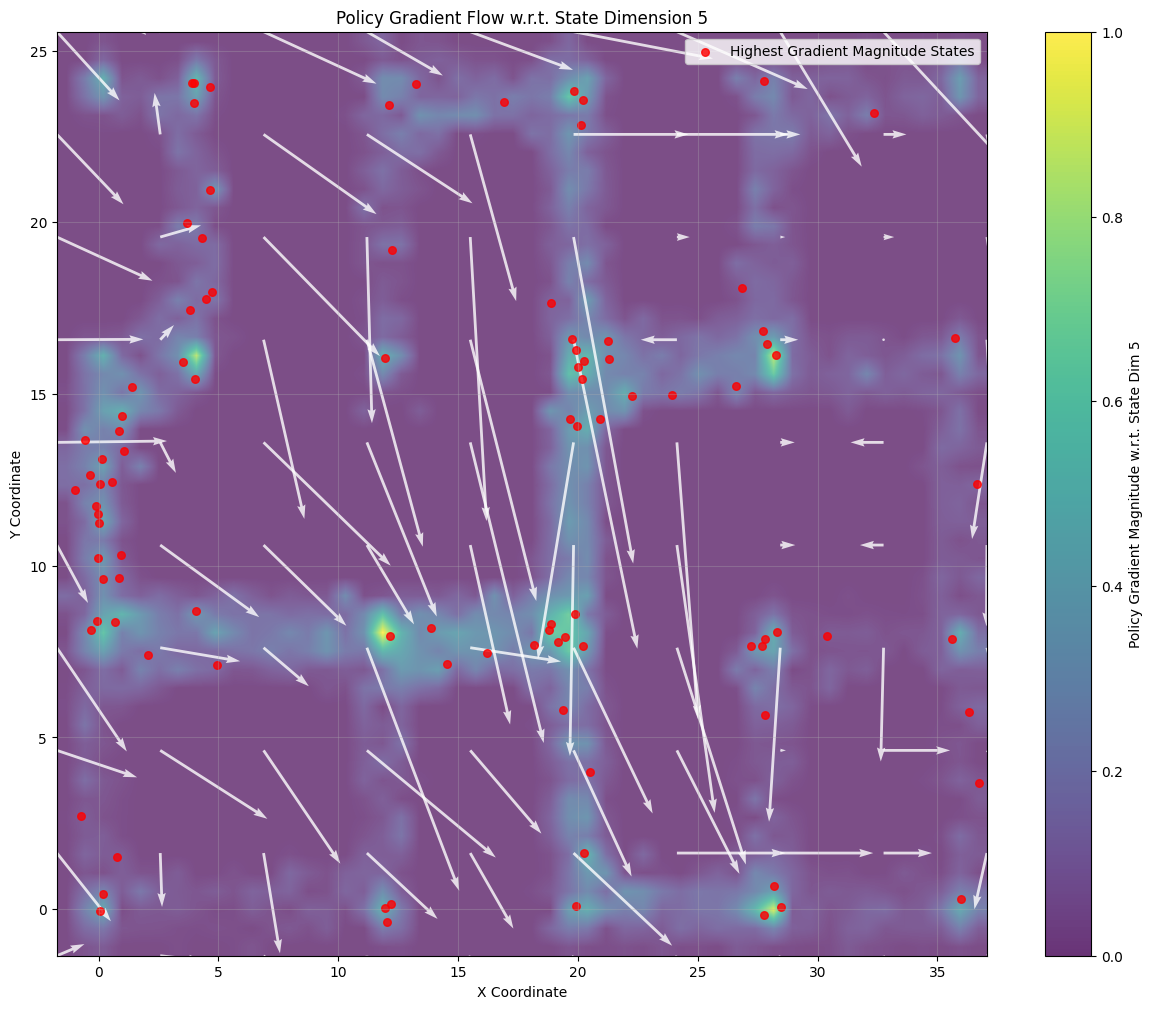

In [35]:
# Convert to JAX array and enable gradient computation
batch_states_jax = jnp.array(batch_states)

# Set the state dimension to analyze (0 for x, 1 for y, etc.)

# Define function to compute policy gradients with respect to state dimensions
def compute_policy_gradients(states):
    def policy_output(state):
        # Get policy action for a single state
        action = iql_actor_fn(state[None, :], temperature=0.0)[0]
        action = jnp.clip(action, -1, 1)
        return action
    
    # Compute Jacobian for each state (action dimensions x state dimensions)
    jacobian_fn = jax.vmap(jax.jacobian(policy_output))
    jacobians = jacobian_fn(states)
    return jacobians

print("Computing policy gradients...")
policy_jacobians = compute_policy_gradients(batch_states_jax)

# Extract position coordinates (assuming first 2 dimensions are x, y)
positions = batch_states[:, :2]
x_coords = positions[:, 0]
y_coords = positions[:, 1]

state_dim_to_analyze = 5 # Change this to analyze different state dimensions

# Extract gradients for the specified state dimension
# policy_jacobians shape: (batch_size, action_dim, state_dim)
grad_wrt_state_dim = np.array(policy_jacobians[:, :, state_dim_to_analyze])  # All action dims w.r.t. specified state dim

# Compute gradient magnitudes (sum over action dimensions)
grad_magnitudes = np.sqrt(np.sum(grad_wrt_state_dim**2, axis=1))

# Set up the plot
plt.figure(figsize=(15, 12))

# Create scatter plot colored by gradient magnitude
# Create 2D histogram/heatmap instead of scatter plot
hist, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=50, weights=grad_magnitudes)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

# Create heatmap
scatter = plt.imshow(hist.T, extent=extent, origin='lower', 
                    cmap='viridis', aspect='auto', interpolation='bilinear')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(f'Policy Gradient Magnitude w.r.t. State Dim {state_dim_to_analyze}')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Policy Gradients with respect to State Dimension {state_dim_to_analyze}')
plt.grid(True, alpha=0.3)

# Give me some of the states that are has the highest gradient magnitude with respect to the state dimension 4


# Sort states by gradient magnitude
sorted_indices = np.argsort(grad_magnitudes)[::-1]

# Get top 10 states
top_states = batch_states_jax[sorted_indices[:100]]

# plot it with red color
plt.scatter(top_states[:, 0], top_states[:, 1], color='red', alpha=0.6, s=20)
plt.show()

# Create a new figure for gradient flow visualization
plt.figure(figsize=(15, 12))

# Create a grid for sampling gradient vectors
x_min, x_max = x_coords.min(), x_coords.max()
y_min, y_max = y_coords.min(), y_coords.max()

# Create a coarser grid for visualization
grid_density = 10
x_grid = np.linspace(x_min, x_max, grid_density)
y_grid = np.linspace(y_min, y_max, grid_density)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Sample states at grid points (assuming other state dimensions are zero or mean values)
grid_states = []
for i in range(grid_density):
    for j in range(grid_density):
        # Create a state vector with x, y at grid point and other dims as mean
        state = np.mean(batch_states_jax, axis=0)  # Start with mean state
        state = state.at[0].set(X_grid[i, j])  # Set x coordinate
        state = state.at[1].set(Y_grid[i, j])  # Set y coordinate
        grid_states.append(state)

grid_states = jnp.array(grid_states)

# Compute gradients at grid points
grid_gradients = compute_policy_gradients(grid_states)
grid_grad_wrt_state_dim = np.array(grid_gradients[:, :, state_dim_to_analyze])

# Compute gradient vectors (we'll use the first two action dimensions for visualization)
U = grid_grad_wrt_state_dim[:, 0].reshape(grid_density, grid_density)  # x-component of gradient
V = grid_grad_wrt_state_dim[:, 1].reshape(grid_density, grid_density)  # y-component of gradient

# Create the background heatmap
hist, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=50, weights=grad_magnitudes)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
plt.imshow(hist.T, extent=extent, origin='lower', cmap='viridis', aspect='auto', interpolation='bilinear', alpha=0.7)

# Add gradient flow arrows
plt.quiver(X_grid, Y_grid, U, V, angles='xy', scale_units='xy', scale=1, 
           color='white', alpha=0.8, width=0.003)

# Add colorbar
cbar = plt.colorbar()
cbar.set_label(f'Policy Gradient Magnitude w.r.t. State Dim {state_dim_to_analyze}')

# Highlight top gradient magnitude states
plt.scatter(top_states[:, 0], top_states[:, 1], color='red', alpha=0.8, s=30, 
           label='Highest Gradient Magnitude States')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title(f'Policy Gradient Flow w.r.t. State Dimension {state_dim_to_analyze}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#array([ 5,  4, 12, 11, 14,  3, 13,  2,  6,  8, 15, 17, 16, 18, 10, 19,  7, 28, 21, 20, 26, 25,  9, 27, 23, 22, 24])
# 2 15  4  3 12  5 11 16  6 17 14 20  8 25 18  7 13 26  9 19 28 23 27 21 22 24 10

In [ ]:
# Measure the gradient of the Q function w.r.t. the state dimension

